# Resident risk flag — “falling through the cracks” (Hiraya Haven)

**Pipeline:** Predict which residents are likely to experience a safety incident in the **next month**, and explain correlates of elevated risk.

**Data:** `residents`, `incident_reports`, `home_visitations`, `process_recordings`, `education_records`, `health_wellbeing_records` (loaded from `../Data/hiraya.db`).

**Outputs:**
- Predictive model: 1-month-ahead **incident risk** per resident (triage signal)
- Explanatory model: interpretable **associations** for staff discussion (not causal claims)

> Privacy note: This notebook avoids using free-text `notes_restricted` fields as features.

> **IS455 pipeline structure:** (1) Problem framing → (2) Data acquisition, preparation & exploration → (3) Modeling → (4) Evaluation & selection → (5) Feature selection & interpretation → (6) Explanatory analysis (associations; not causal proof) → (7) Deployment.

## 1. Problem framing

Hiraya Haven’s staff worry about residents “falling through the cracks” when caseloads grow and issues escalate between formal check-ins (`IntexContext.txt`). A lightweight **risk flag** helps staff prioritize supervision, home visitation, and case conferences.

**Business question:** *Which residents are at elevated risk of a safety incident in the next month?*

**Who cares:** social workers, safehouse managers, and program leadership.

### Predictive vs explanatory

- **Predictive goal:** 1-month-ahead classification: `will_have_incident_next_month`.
- **Explanatory goal:** Identify correlates (documentation activity, visitation outcomes, health/education trends) with an interpretable model.

**Success metrics:** ROC-AUC + PR-AUC (if class imbalance is high), plus recall at a practical threshold (false negatives are costly).

## 2. Data acquisition, preparation & exploration

**Spine:** resident-month panel.

- Aggregate `incident_reports` by `(resident_id, month)`.
- Aggregate `process_recordings` by `(resident_id, month)` using `concerns_flagged`, `referral_made`, session counts.
- Aggregate `home_visitations` by `(resident_id, month)` using follow-up flags and outcomes.
- Join monthly `education_records` and `health_wellbeing_records` (already resident-month).

**Target construction:** `will_have_incident_next_month = 1` if the resident has ≥1 incident in month `t+1`.

**Leakage control:** features are from month `t` (and earlier lags); target is month `t+1`.

In [1]:
# ============================================================================
# Resident risk flag — Build resident×month spine from multiple event sources
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Every table contributes resident_id + month keys; union+dedupe defines panel rows.
# Merges static resident attributes (case status, risk levels) for later modeling.
#
from __future__ import annotations

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
DB_PATH = ROOT / "Data" / "hiraya.db"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found at {DB_PATH}. Create it first with db/sqlite/load_csv_to_sqlite.py"
    )


def read_table(conn: sqlite3.Connection, table: str) -> pd.DataFrame:
    return pd.read_sql_query(f'SELECT * FROM "{table}"', conn)


with sqlite3.connect(DB_PATH) as conn:
    residents = read_table(conn, "residents")
    incidents = read_table(conn, "incident_reports")
    process_recordings = read_table(conn, "process_recordings")
    home_visitations = read_table(conn, "home_visitations")
    education = read_table(conn, "education_records")
    health = read_table(conn, "health_wellbeing_records")

# Parse dates
incidents["incident_date"] = pd.to_datetime(incidents["incident_date"], errors="coerce")
process_recordings["session_date"] = pd.to_datetime(process_recordings["session_date"], errors="coerce")
home_visitations["visit_date"] = pd.to_datetime(home_visitations["visit_date"], errors="coerce")
education["record_date"] = pd.to_datetime(education["record_date"], errors="coerce")
health["record_date"] = pd.to_datetime(health["record_date"], errors="coerce")

# Month keys
incidents["month"] = incidents["incident_date"].dt.to_period("M").dt.to_timestamp()
process_recordings["month"] = process_recordings["session_date"].dt.to_period("M").dt.to_timestamp()
home_visitations["month"] = home_visitations["visit_date"].dt.to_period("M").dt.to_timestamp()
education["month"] = education["record_date"].dt.to_period("M").dt.to_timestamp()
health["month"] = health["record_date"].dt.to_period("M").dt.to_timestamp()

# Resident-month spine from available months across sources
months = pd.concat(
    [
        incidents[["resident_id", "month"]],
        process_recordings[["resident_id", "month"]],
        home_visitations[["resident_id", "month"]],
        education[["resident_id", "month"]],
        health[["resident_id", "month"]],
    ],
    ignore_index=True,
).dropna().drop_duplicates()

spine = months.merge(
    residents[[
        "resident_id",
        "safehouse_id",
        "case_status",
        "case_category",
        "initial_risk_level",
        "current_risk_level",
    ]],
    on="resident_id",
    how="left",
)

spine = spine.sort_values(["resident_id", "month"]).reset_index(drop=True)
spine.head()

,resident_id,month,safehouse_id,case_status,case_category,initial_risk_level,current_risk_level
0,1,2023-10-01,4,Active,Neglected,Critical,High
1,1,2023-11-01,4,Active,Neglected,Critical,High
2,1,2023-12-01,4,Active,Neglected,Critical,High
3,1,2024-01-01,4,Active,Neglected,Critical,High
4,1,2024-02-01,4,Active,Neglected,Critical,High


In [2]:
# ============================================================================
# Aggregate incidents, sessions, visits, education, health to resident-month features
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Counts fill to zero where no events; continuous scores stay NaN until filled in modeling step.
# Lags same-month signals within resident; target is next month's incident presence.
#
# Aggregate features by resident-month

incident_month = (
    incidents.groupby(["resident_id", "month"], as_index=False)
    .agg(
        incident_count=("incident_id", "count"),
        high_sev_incidents=("severity", lambda s: int((s == "High").sum())),
        unresolved_incidents=("resolved", lambda s: int((s == 0).sum())),
    )
)

proc_month = (
    process_recordings.groupby(["resident_id", "month"], as_index=False)
    .agg(
        sessions=("recording_id", "count"),
        concerns=("concerns_flagged", lambda s: int((s == 1).sum())),
        referrals=("referral_made", lambda s: int((s == 1).sum())),
        progress_noted=("progress_noted", lambda s: int((s == 1).sum())),
    )
)

visit_month = (
    home_visitations.groupby(["resident_id", "month"], as_index=False)
    .agg(
        visits=("visitation_id", "count"),
        follow_up_needed=("follow_up_needed", lambda s: int((s == 1).sum())),
        safety_concerns=("safety_concerns_noted", lambda s: int((s == 1).sum())),
        unfavorable_outcomes=("visit_outcome", lambda s: int((s == "Unfavorable").sum())),
    )
)

edu_month = education[[
    "resident_id",
    "month",
    "attendance_rate",
    "progress_percent",
    "completion_status",
]].copy()

health_month = health[[
    "resident_id",
    "month",
    "general_health_score",
    "nutrition_score",
    "sleep_quality_score",
    "energy_level_score",
]].copy()

panel = (
    spine
    .merge(incident_month, on=["resident_id", "month"], how="left")
    .merge(proc_month, on=["resident_id", "month"], how="left")
    .merge(visit_month, on=["resident_id", "month"], how="left")
    .merge(edu_month, on=["resident_id", "month"], how="left")
    .merge(health_month, on=["resident_id", "month"], how="left")
)

# Fill missing counts with 0; keep continuous as NaN for now
for c in [
    "incident_count",
    "high_sev_incidents",
    "unresolved_incidents",
    "sessions",
    "concerns",
    "referrals",
    "progress_noted",
    "visits",
    "follow_up_needed",
    "safety_concerns",
    "unfavorable_outcomes",
]:
    panel[c] = panel[c].fillna(0).astype(int)

# Lag features within resident
panel = panel.sort_values(["resident_id", "month"]).copy()
g = panel.groupby("resident_id", group_keys=False)

panel["incident_lag1"] = g["incident_count"].shift(1)
panel["concerns_lag1"] = g["concerns"].shift(1)
panel["progress_percent_lag1"] = g["progress_percent"].shift(1)
panel["health_score_lag1"] = g["general_health_score"].shift(1)

# Target: incident next month
panel["incident_next_month"] = g["incident_count"].shift(-1)
panel["will_have_incident_next_month"] = (panel["incident_next_month"].fillna(0) > 0).astype(int)

panel[["incident_count", "will_have_incident_next_month"]].value_counts().head(10)

incident_count  will_have_incident_next_month
0               0                                977
                1                                 84
1               0                                 79
                1                                  8
2               0                                  5
3               0                                  1
Name: count, dtype: int64

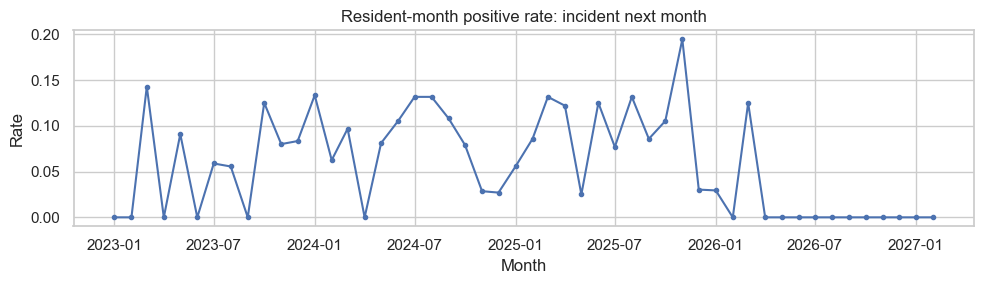

,month,n,positives,positive_rate
45,2026-10-01,2,0,0.0
46,2026-11-01,1,0,0.0
47,2026-12-01,1,0,0.0
48,2027-01-01,1,0,0.0
49,2027-02-01,1,0,0.0


In [3]:
# ============================================================================
# EDA — Positive rate for 'incident next month' over time
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Checks label drift and whether risk is stable across months before trusting metrics.
#
# Quick EDA: class balance over time

by_month = panel.groupby("month", as_index=False).agg(
    n=("resident_id", "count"),
    positives=("will_have_incident_next_month", "sum"),
)
by_month["positive_rate"] = by_month["positives"] / by_month["n"]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(by_month["month"], by_month["positive_rate"], marker="o", ms=3)
ax.set_title("Resident-month positive rate: incident next month")
ax.set_xlabel("Month")
ax.set_ylabel("Rate")
plt.tight_layout()
plt.show()

by_month.tail()

## 3. Modeling

**Predictive model:** Logistic regression with standardized numeric features and `class_weight="balanced"`.

- Uses resident-month rows.
- Uses **time-series cross-validation** on the month index (no shuffling).

**Explanatory model:** The same logistic regression is also interpretable (sign/direction of coefficients). We’ll present standardized coefficients and highlight the strongest associations.

> Note: We intentionally do not use `notes_restricted`, `session_narrative`, or other free-text fields as model inputs.

In [4]:
# ============================================================================
# Model — Logistic regression with chronological holdout by month index
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Rows sorted by time; last 25% of months held out. Safer than mixing future months into train.
# Outputs ROC-AP-F1 at 0.5 threshold; threshold can be tuned for recall vs precision.
#
# Build modeling dataset

features = [
    # same-month signals
    "incident_count",
    "high_sev_incidents",
    "unresolved_incidents",
    "sessions",
    "concerns",
    "referrals",
    "visits",
    "follow_up_needed",
    "safety_concerns",
    "unfavorable_outcomes",
    "attendance_rate",
    "progress_percent",
    "general_health_score",
    "nutrition_score",
    "sleep_quality_score",
    "energy_level_score",
    # lags
    "incident_lag1",
    "concerns_lag1",
    "progress_percent_lag1",
    "health_score_lag1",
]

model = panel.dropna(subset=["month"]).copy()
model = model.sort_values(["month", "resident_id"]).reset_index(drop=True)

X = model[features].fillna(0)
y = model["will_have_incident_next_month"].astype(int)

# Map month to an integer time index for a single chronological holdout
month_order = pd.Series(sorted(model["month"].unique()))
month_to_idx = {m: i for i, m in enumerate(month_order)}
model["month_idx"] = model["month"].map(month_to_idx)

# Rows are sorted by month_idx so the holdout is later calendar months
order = np.argsort(model["month_idx"].values)
X = X.iloc[order].reset_index(drop=True)
y = y.iloc[order].reset_index(drop=True)
month_idx = model["month_idx"].iloc[order].reset_index(drop=True)

clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                max_iter=500,
                class_weight="balanced",
                solver="liblinear",
                random_state=42,
            ),
        ),
    ]
)

# Walk-forward evaluation by month blocks
# We split by rows, but ensure splits fall on month boundaries by using month_idx.
# Simple approach: take unique months and use expanding windows.
unique_months = sorted(month_idx.unique())
cut = unique_months[int(0.75 * len(unique_months))]
train_mask = month_idx < cut
test_mask = ~train_mask

clf.fit(X[train_mask], y[train_mask])
proba = clf.predict_proba(X[test_mask])[:, 1]

roc = roc_auc_score(y[test_mask], proba) if y[test_mask].nunique() > 1 else float("nan")
ap = average_precision_score(y[test_mask], proba)

# threshold at 0.5 for a simple report (you can tune for higher recall)
pred = (proba >= 0.5).astype(int)
f1 = f1_score(y[test_mask], pred, zero_division=0)

print(f"Holdout months >= {month_order.iloc[cut].date()} | ROC-AUC={roc:.3f} AP={ap:.3f} F1@0.5={f1:.3f}")

Holdout months >= 2026-02-01 | ROC-AUC=0.904 AP=0.125 F1@0.5=0.200


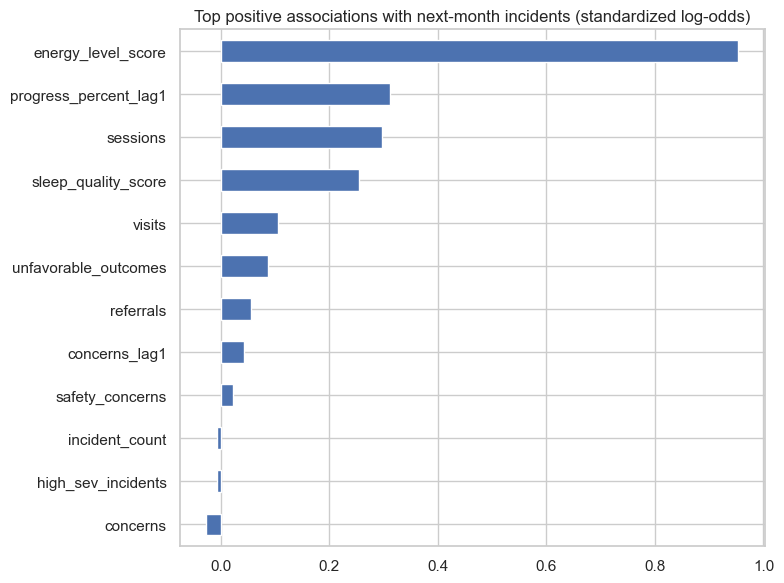

(progress_percent       -0.868223
 general_health_score   -0.168361
 follow_up_needed       -0.139591
 attendance_rate        -0.129613
 incident_lag1          -0.098462
 unresolved_incidents   -0.088147
 health_score_lag1      -0.058522
 nutrition_score        -0.027421
 concerns               -0.026362
 high_sev_incidents     -0.007706
 incident_count         -0.007561
 safety_concerns         0.022415
 dtype: float64,
 concerns                -0.026362
 high_sev_incidents      -0.007706
 incident_count          -0.007561
 safety_concerns          0.022415
 concerns_lag1            0.042137
 referrals                0.055891
 unfavorable_outcomes     0.086613
 visits                   0.106085
 sleep_quality_score      0.254683
 sessions                 0.296670
 progress_percent_lag1    0.311683
 energy_level_score       0.953231
 dtype: float64)

In [5]:
# ============================================================================
# Explanatory coefficients — standardized log-odds
# ============================================================================
# Notebook code cell overview — see inline comments below.
#
# Bar plot highlights direction of association with next-month incidents; still not causal.
#
# Explanatory: standardized coefficients (directional associations)

coefs = pd.Series(
    clf.named_steps["lr"].coef_.ravel(),
    index=features,
).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
coefs.tail(12).plot(kind="barh", ax=ax)
ax.set_title("Top positive associations with next-month incidents (standardized log-odds)")
plt.tight_layout()
plt.show()

coefs.head(12), coefs.tail(12)

## 4. Evaluation & selection

- **ROC-AUC** measures ranking quality (higher means better separation).
- **Average Precision (AP)** is more informative when positives are rare.
- In Hiraya Haven’s context, **false negatives** are costlier than false positives. In practice you’d pick a threshold to meet a desired **recall** (e.g., catch 80–90% of next-month incident cases) and treat flags as “review prompts,” not decisions.

## 5. Feature selection & interpretation

Use **standardized logistic coefficients** (see plot above) to discuss which signals are strongest for the model; distinguish “what the model used” from **documentation intensity** vs. underlying risk.

## 6. Explanatory analysis (associations; not causal proof)

This model discovers **associations** (correlations) between resident-month signals and next-month incidents. It does **not** prove causality.

- Some predictors may reflect **documentation intensity** (more sessions recorded) rather than true underlying risk.
- Incidents may drive increased visits/sessions (**reverse causation**) and unmeasured factors (staffing, external threats) may drive both.

Use the coefficients to generate hypotheses for staff discussion and to guide what data you might collect next (e.g., staffing ratios, partner service levels).

## 7. Deployment

**Recommended integration:**
- Add a “Resident risk flags” panel to the staff portal showing top-N residents by predicted probability for the current month.
- Store monthly scores in a table like `resident_risk_scores(resident_id, month_start, risk_probability, model_version)`.
- Refresh nightly or weekly. Track drift and re-train monthly.